## NOTE FROM AUTHOR
This basic K-Means Clustering algorithm was based off of my Mathematics and Modelling professor Angelica Pathon. I after understanding the algorithm, I fed the code to the AI to help give me a guide for writing this code myself. This code is majority written by me, with some help for comprehension from AI, as well as the final plotting of the graph was done by AI.

---


This is a classic implementation of the **K-Means Clustering** algorithm. To rewrite this yourself, you need to think of it as a cycle: **Initialize $\to$ Assign $\to$ Move $\to$ Repeat.**

---

### Task 1: Setup and Data Loading
Prepare your workspace and bring in the data.
* **Load the data:** Use `np.loadtxt` to get the coordinates.
* **Prepare the "Work Matrix":** Create a copy of the data but add an extra column (using `np.zeros` or `np.column_stack`) to hold the cluster labels later.
    * *Self-Check:* Does your new matrix have a shape of `(numdata, 3)`?

### Task 2: The "Seed" (Initialization)
Before you can group points, you need starting centers.
* **Define Boundaries:** Set a `min` and `max` (like 0 and 6).
* **Generate Centroids:** Create a $3 \times 2$ matrix of random numbers. 
    * *Tip:* Try `np.random.uniform(min, max, size=(nclusters, idim))` to do it in one line without loops.

### Task 3: The Distance Tool
You need a way to measure how far a point is from a center.
* **Write the function:** It should take two vectors and return the squared difference.
* **The Formula:** $$\sum (v1_i - v2_i)^2$$

### Task 4: The Assignment Logic
This is where points "pick" their closest center.
* **Assign One Point:** Write a function that takes one coordinate and compares it against all rows in your `centroid` matrix.
* **Assign All Points:** Loop through your data matrix, find the best label for each row, and save that label into the 3rd column.
* **Count the results:** Create a `counts` array (cardinality) to track how many points went to Cluster 0, 1, and 2.

### Task 5: The "Move" (Update Centroids)
Now that points have labels, the centroids must move to the **center** of their new groups.
* **Calculate the Mean:** For each cluster ID, find all points belonging to it and calculate their average $x_1$ and $x_2$.
* **The Formula:** $$\text{New Centroid}_k = \frac{1}{\text{Count}_k} \sum \text{Points in Cluster}_k$$
* **Update:** Replace the old `centroid` matrix with these new average positions.

### Task 6: The Main Loop & Convergence
Run the cycle until the centers stop moving.
* **Create the `for` loop:** Set a maximum number of iterations (e.g., 20).
* **Check for Convergence:** Calculate the distance between the `old_centroid` and `new_centroid`. If the movement is smaller than a tiny number (`epsilon`), `break` the loop early.
    

### Task 7: Visualization
See your results.
* **Filter by Label:** Create separate arrays for points labeled 0, 1, and 2.
* **Plot:** Use `plt.plot()` with different colors for each group and a special marker (like `'D'` for Diamond) for the centroids.

In [808]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import rcParams
rcParams['figure.autolayout'] = True

In [809]:
url = 'clusters.csv'
data = np.loadtxt(url, delimiter=',')
rows, columns = np.shape(data)
data_w_labels = np.zeros((rows, columns+1))

for i in range(rows):
    for j in range(columns):
        data_w_labels[i, j] = data[i,j]

data_w_labels

array([[5.36963 , 6.022099, 0.      ],
       [4.301836, 1.910676, 0.      ],
       [1.831361, 2.393412, 0.      ],
       [1.605672, 5.040567, 0.      ],
       [1.646543, 4.623993, 0.      ],
       [1.741405, 4.799476, 0.      ],
       [3.438456, 1.219201, 0.      ],
       [1.836985, 4.616158, 0.      ],
       [2.979648, 1.541938, 0.      ],
       [5.716591, 5.495285, 0.      ],
       [5.477186, 4.57172 , 0.      ],
       [1.739006, 4.265418, 0.      ],
       [4.710346, 6.041728, 0.      ],
       [2.827088, 1.561865, 0.      ],
       [3.41027 , 2.470423, 0.      ],
       [1.402328, 4.499826, 0.      ],
       [1.693269, 5.325717, 0.      ],
       [5.199118, 4.292553, 0.      ],
       [3.230002, 2.320945, 0.      ],
       [0.631603, 5.461425, 0.      ],
       [3.375837, 2.365149, 0.      ],
       [5.838641, 5.491008, 0.      ],
       [1.943709, 5.367262, 0.      ],
       [0.356371, 5.21936 , 0.      ],
       [3.733958, 1.578272, 0.      ],
       [3.475168, 0.96228

In [810]:
# seeding and initalisation
cmax = data.max()
cmin = data.min()

c_count = 3

def init_centroids(k, cmin, cmax):
    global centroids
    centroids = np.random.uniform(cmin, cmax, size=(c_count, 2))
    return centroids

init_centroids(c_count, cmin, cmax)

array([[5.99039275, 5.86759244],
       [5.90653033, 5.48602805],
       [0.6064198 , 2.0780605 ]])

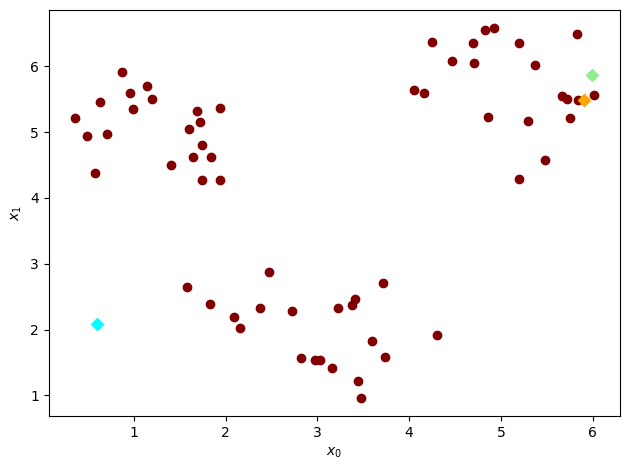

In [811]:
plt.xlabel(r'$x_0$')
plt.ylabel(r'$x_1$')
plt.scatter(data[:,0], data[:,1], color='maroon')
plt.plot(centroids[0,0],centroids[0,1],'D',color='lightgreen')
plt.plot(centroids[1,0],centroids[1,1],'D',color='orange')
plt.plot(centroids[2,0],centroids[2,1],'D',color='cyan')
plt.show()

In [812]:
# measuring distance
def vector_distance(v1, v2):
    dist = 0
    
    for i in range(columns):
        dist += np.sum((v1[i] - v2[i])**2)
    return dist



In [813]:

def closest_centroid():
    centroid_tally = np.zeros(c_count)

    shortest_distace_now = np.zeros((c_count, columns))
    counter = 0

    for k in range(0, c_count):
        counter += 1
        shortest_distace_now[k, 1] += counter
        
    for i in range(rows):
        for j in range(c_count):
            shortest_distace_now[j, 0] = vector_distance(data[i],centroids[j])
        
        
        winning_index = np.argmin(shortest_distace_now[:, 0]) + 1
        data_w_labels[i, columns] = winning_index

        centroid_tally[winning_index - 1] += 1
    
    print('closest centroids calculated, returning the centroid_tally:','\n', centroid_tally)

closest_centroid()


closest centroids calculated, returning the centroid_tally: 
 [ 9. 11. 40.]


### Task 5: The "Move" (Update Centroids)
Now that points have labels, the centroids must move to the **center** of their new groups.
* **Calculate the Mean:** For each cluster ID, find all points belonging to it and calculate their average $x_1$ and $x_2$.
* **The Formula:** $$\text{New Centroid}_k = \frac{1}{\text{Count}_k} \sum \text{Points in Cluster}_k$$
* **Update:** Replace the old `centroid` matrix with these new average positions.

In [814]:
def update_centroids():
    new_centroids = np.zeros((c_count, columns))
    
    for k in range(c_count):
        label_to_find = k + 1
        mask = (data_w_labels[:,-1] == label_to_find)
        cluster_points = data_w_labels[mask]

        if len(cluster_points) > 0:
            new_centroids[k] = np.mean(cluster_points[:, 0:columns], axis=0)
            # print(new_centroids)
            print(np.mean(cluster_points[:, 0:columns], axis=0))
        else:
            new_centroids[k] = centroids[k]

    return new_centroids

### Task 6: The Main Loop & Convergence
Run the cycle until the centers stop moving.
* **Create the `for` loop:** Set a maximum number of iterations (e.g., 20).
* **Check for Convergence:** Calculate the distance between the `old_centroid` and `new_centroid`. If the movement is smaller than a tiny number (`epsilon`), `break` the loop early.

closest centroids calculated, returning the centroid_tally: 
 [ 9. 11. 40.]
[4.91670144 6.31461722]
[5.27551064 5.25659345]
[2.11780603 3.5288143 ]


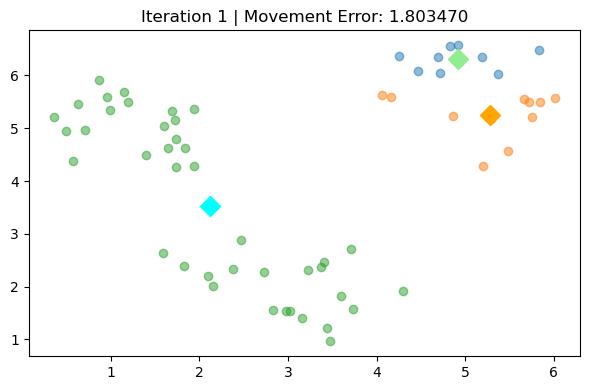

Iteration 1, Error: 1.8034702560116513
closest centroids calculated, returning the centroid_tally: 
 [11.  9. 40.]
[4.76960227 6.18797464]
[5.53503389 5.17626244]
[2.11780603 3.5288143 ]


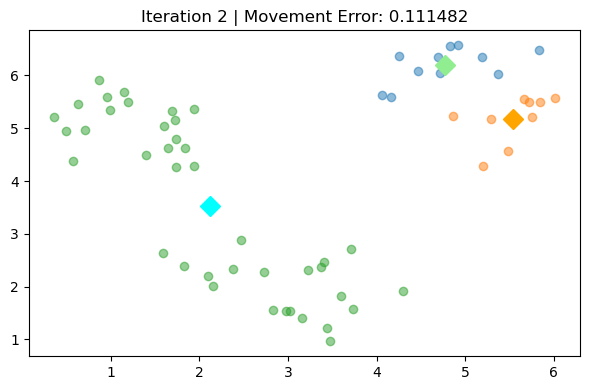

Iteration 2, Error: 0.11148190065796204
closest centroids calculated, returning the centroid_tally: 
 [11.  9. 40.]
[4.76960227 6.18797464]
[5.53503389 5.17626244]
[2.11780603 3.5288143 ]


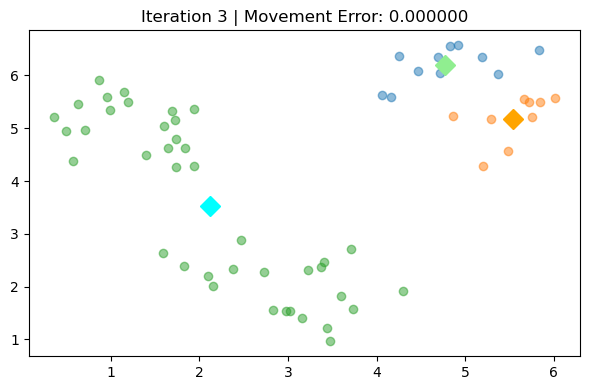

Iteration 3, Error: 0.0
Converged!


In [815]:
for k in range(max_its):
    # 1. IMPORTANT: Re-assign points to the CURRENT centroids
    closest_centroid() 
    
    # 2. Calculate where the centroids SHOULD move to
    new_centroids = update_centroids()
    
    # 3. Calculate the error (how far they moved)
    err = vector_distance(new_centroids, centroids)
    
    # 4. Update the actual centroids for the NEXT iteration
    centroids = np.copy(new_centroids) 

    plt.figure(figsize=(6,4))
    plt.title(f"Iteration {k+1} | Movement Error: {err:.6f}")
        # Plot points colored by their assigned cluster
    for i in range(1, c_count + 1):
        mask = (data_w_labels[:, -1] == i)
        plt.scatter(data_w_labels[mask, 0], data_w_labels[mask, 1], alpha=0.5)
    plt.plot(centroids[0,0], centroids[0,1], 'D', color='lightgreen', markersize=10)
    plt.plot(centroids[1,0], centroids[1,1], 'D', color='orange', markersize=10)
    plt.plot(centroids[2,0], centroids[2,1], 'D', color='cyan', markersize=10)
    plt.show()

    print(f"Iteration {k+1}, Error: {err}")

    if (err < epsilon):
        print('Converged!')
        break

## CLOSING REMARK FROM AUTHOR
This algorithm successfully finds the true mean points of the clusters often, but not always. In this code implementation, I intentionally leave the code as is to show that without more careful initial plotting of the random centroids, the algorithm can still find the mathematical optimal point from its starting points, but which may not necessarily be the most optimal answer that can be gained.

Feel free to run press the run all button to randomly initialise the beginning centroids and see how they may get stuck at a local minimum point.